# UAV stage visualizer

Chạy một ảnh UAV qua pipeline: preprocess → segment → contours → polygons → CDT → Ekeland/MFCA.

Notebook này lưu 7 ảnh riêng vào `outputs/uav_stage_viz/<ten_anh>/`.
Có thêm một hình mesh-only cho CDT ở stage 5.1 để không bị nhà phía sau chồng lên.
Nếu chưa có pose CSV, notebook sẽ fallback sang center-crop + resize để vẫn chạy được.

In [3]:
import sys
import math
from pathlib import Path

import cv2
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.patches import Polygon as MplPolygon, Wedge
from PIL import Image
from scipy.spatial import Delaunay
from shapely.geometry import Point, Polygon

NOTEBOOK_DIR = Path.cwd().resolve()

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "localization").exists():
            return candidate
    raise FileNotFoundError(f"Could not find the LocalizationUAV repo above {start}")

def _first_existing(*paths: Path) -> Path:
    for path in paths:
        if path.exists():
            return path
    raise FileNotFoundError(f"None of these paths exist: {paths}")

REPO_ROOT = _find_repo_root(NOTEBOOK_DIR)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from localization import load_model, process_uav
from localization.geometry import (
    build_dual_graph,
    calculate_ekeland_angles_on_boundary,
    expand_from_seed_triangle,
    interior_angles,
)
from localization.segmentation import (
    contour_to_polygon,
    extract_contours_from_mask,
    filter_large_polygons_dynamic,
    segment_image,
)

print("Notebook:", NOTEBOOK_DIR)
print("Repo    :", REPO_ROOT)

Notebook: D:\bk_study_stuff\paper6\LocalizationUAV\notebooks
Repo    : D:\bk_study_stuff\paper6\LocalizationUAV


## Cấu hình đầu vào

Chỉ cần sửa `IMAGE_PATH`. `POSE_CSV_PATH` là tùy chọn.
Nếu `POSE_CSV_PATH = None` hoặc file không tồn tại, notebook sẽ không xoay ảnh theo pose mà dùng fallback center-crop + resize.

In [4]:
IMAGE_PATH = Path(r"D:\bk_study_stuff\paper6\UAV_VisLoc_dataset\03\drone\03_0049.JPG")  # đổi chỗ này
POSE_CSV_PATH = Path(r"D:\bk_study_stuff\paper6\UAV_VisLoc_dataset\03\03.csv")

MODEL_PATH = _first_existing(REPO_ROOT / "best_model.pth", NOTEBOOK_DIR / "best_model.pth")
OUTPUT_DIR = REPO_ROOT / "notebooks" / "outputs" / "uav_stage_viz" / IMAGE_PATH.stem
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEGMENT_SCORE_THRESHOLD = 0.5
SEGMENT_MIN_AREA = 50.0
SEGMENT_TOLERANCE_PX = 2.0
MAX_SIZE_QUANTILE = 0.995
EKE_MAX_DEPTH = 4
EKE_VISUAL_TOP_N = 120

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Missing checkpoint: {MODEL_PATH}")
if not IMAGE_PATH.exists():
    raise FileNotFoundError(f"Missing input image: {IMAGE_PATH}")

print("Device :", DEVICE)
print("Output :", OUTPUT_DIR)
print("Image  :", IMAGE_PATH)
print("Pose   :", POSE_CSV_PATH)

Device : cuda
Output : D:\bk_study_stuff\paper6\LocalizationUAV\notebooks\outputs\uav_stage_viz\03_0049
Image  : D:\bk_study_stuff\paper6\UAV_VisLoc_dataset\03\drone\03_0049.JPG
Pose   : D:\bk_study_stuff\paper6\UAV_VisLoc_dataset\03\03.csv


In [5]:
def save_array_stage(image_array, path: Path, title: str, cmap=None, figsize=(8, 8), dpi: int = 180):
    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax.imshow(image_array, cmap=cmap)
    ax.set_title(title, fontsize=12)
    ax.axis("off")
    fig.savefig(path, dpi=dpi, bbox_inches="tight", pad_inches=0.08, facecolor="white")
    plt.close(fig)
    return path


def save_figure_stage(fig, path: Path, dpi: int = 180):
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=dpi, bbox_inches="tight", pad_inches=0.08, facecolor="white")
    plt.close(fig)
    return path


def fallback_preprocess(image_path: Path, out_size: int = 500):
    img_raw = Image.open(image_path).convert("RGB")
    w, h = img_raw.size
    side = min(w, h)
    left = (w - side) // 2
    top = (h - side) // 2
    cropped = img_raw.crop((left, top, left + side, top + side))
    processed = cropped.resize((out_size, out_size), Image.BICUBIC)
    meta = {
        "height": None,
        "Pitch (Omega)": None,
        "Roll (Kappa)": None,
        "Yaw (Phi)": None,
        "yaw_applied": None,
        "mode": "center-crop + resize",
    }
    return img_raw, processed, meta


def _interior_simplex_mask(tri, polygon_np):
    poly = Polygon(polygon_np)
    if not poly.is_valid:
        poly = poly.buffer(0)
    if poly.is_empty or poly.area <= 0.0:
        return np.ones(len(tri.simplices), dtype=bool)
    centroids = polygon_np[tri.simplices].mean(axis=1)
    mask = np.fromiter(
        (poly.contains(Point(float(cx), float(cy))) for cx, cy in centroids),
        dtype=bool,
        count=len(tri.simplices),
    )
    return mask if mask.any() else np.ones(len(tri.simplices), dtype=bool)


def make_contour_overlay(base_rgb, contours):
    base_bgr = cv2.cvtColor(np.asarray(base_rgb).copy(), cv2.COLOR_RGB2BGR)
    if not contours:
        return cv2.cvtColor(base_bgr, cv2.COLOR_BGR2RGB)
    cmap = plt.get_cmap("hsv", max(len(contours), 1))
    for idx, contour in enumerate(contours):
        color = cmap(idx % cmap.N)
        color_bgr = (int(round(255 * color[2])), int(round(255 * color[1])), int(round(255 * color[0])))
        pts = np.asarray(contour, dtype=np.float32).reshape(-1, 2)
        pts = np.round(pts).astype(np.int32).reshape(-1, 1, 2)
        cv2.drawContours(base_bgr, [pts], -1, color_bgr, 2, lineType=cv2.LINE_AA)
    return cv2.cvtColor(base_bgr, cv2.COLOR_BGR2RGB)


def make_polygon_overlay(base_rgb, polygons):
    base_bgr = cv2.cvtColor(np.asarray(base_rgb).copy(), cv2.COLOR_RGB2BGR)
    fill_bgr = np.zeros_like(base_bgr)
    for poly in polygons:
        pts = np.round(np.asarray(poly, dtype=np.float32)).astype(np.int32).reshape(-1, 1, 2)
        cv2.fillPoly(fill_bgr, [pts], (0, 255, 0))
        cv2.polylines(base_bgr, [pts], True, (0, 0, 255), 2, lineType=cv2.LINE_AA)
    blended = cv2.addWeighted(base_bgr, 1.0, fill_bgr, 0.28, 0.0)
    return cv2.cvtColor(blended, cv2.COLOR_BGR2RGB)


def collect_triangle_records(polygons, max_depth: int = 4):
    records = []
    descriptors = []
    for polygon_idx, polygon in enumerate(polygons):
        poly_np = np.asarray(polygon, dtype=np.float64)
        if poly_np.shape[0] < 3:
            continue
        try:
            tri = Delaunay(poly_np)
        except Exception:
            continue
        interior_mask = _interior_simplex_mask(tri, poly_np)
        if not interior_mask.any():
            continue
        dual = build_dual_graph(tri, valid_mask=interior_mask)
        for seed_idx in np.where(interior_mask)[0]:
            seed_idx = int(seed_idx)
            simplex = tri.simplices[seed_idx]
            triangle_points = tri.points[simplex]
            expansion = expand_from_seed_triangle(tri, dual, seed_idx, max_iterations=int(max_depth))
            ekeland = calculate_ekeland_angles_on_boundary(tri, expansion)

            e_values = []
            best_vertex = None
            best_angle = -1.0
            best_axis = np.array([1.0, 0.0], dtype=np.float32)

            for vertex_idx in simplex:
                v = int(vertex_idx)
                angle = float(ekeland[v]["ekeland_angle"])
                e_values.append(angle)
                if angle > best_angle:
                    best_angle = angle
                    best_vertex = v
                    best_axis = np.asarray(ekeland[v]["best_axis"], dtype=np.float32)

            alpha1, alpha2, _ = interior_angles(
                tuple(map(float, triangle_points[0])),
                tuple(map(float, triangle_points[1])),
                tuple(map(float, triangle_points[2])),
            )
            descriptor = np.asarray([alpha1, alpha2, *sorted(e_values)], dtype=np.float32)
            descriptors.append(descriptor)
            records.append(
                {
                    "polygon_idx": polygon_idx,
                    "seed_idx": seed_idx,
                    "triangle_points": triangle_points,
                    "best_vertex": int(best_vertex),
                    "best_vertex_point": np.asarray(tri.points[best_vertex], dtype=np.float32),
                    "best_angle": float(best_angle),
                    "best_axis": best_axis,
                    "descriptor": descriptor,
                }
            )
    descriptor_arr = np.vstack(descriptors) if descriptors else np.zeros((0, 5), dtype=np.float32)
    return records, descriptor_arr


def make_cdt_figure(base_rgb, triangle_records):
    fig, ax = plt.subplots(figsize=(8, 8))
    fig.patch.set_facecolor("white")
    ax.imshow(base_rgb)
    ax.axis("off")
    if not triangle_records:
        ax.text(
            0.5,
            0.5,
            "No triangles detected",
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=14,
            color="white",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="black", alpha=0.55),
        )
        ax.set_title("Delaunay Triangulation\n0 triangles", fontsize=12)
        return fig
    cmap = plt.get_cmap("tab20", max(len(triangle_records), 1))
    for idx, rec in enumerate(triangle_records):
        pts = np.asarray(rec["triangle_points"], dtype=np.float32)
        color = cmap(idx % cmap.N)
        ax.add_patch(
            MplPolygon(
                pts,
                closed=True,
                facecolor=(color[0], color[1], color[2], 0.18),
                edgecolor=(color[0], color[1], color[2], 0.85),
                linewidth=0.6,
            )
        )
    ax.set_title(f"Delaunay Triangulation\n{len(triangle_records)} triangles", fontsize=12)
    return fig


def make_ekeland_figure(base_rgb, triangle_records, top_n: int = 120):
    fig, ax = plt.subplots(figsize=(8, 8))
    fig.patch.set_facecolor("white")
    ax.imshow(base_rgb)
    ax.axis("off")
    if not triangle_records:
        ax.text(
            0.5,
            0.5,
            "No Ekeland triangles detected",
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=14,
            color="white",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="black", alpha=0.55),
        )
        ax.set_title("Ekeland (Max Free Cone)\n0 triangles", fontsize=12)
        return fig

    angles = np.asarray([rec["best_angle"] for rec in triangle_records], dtype=np.float32)
    norm = mcolors.Normalize(vmin=0.0, vmax=180.0)
    cmap = plt.get_cmap("turbo")

    for rec in triangle_records:
        pts = np.asarray(rec["triangle_points"], dtype=np.float32)
        color = cmap(norm(float(rec["best_angle"])))
        ax.add_patch(
            MplPolygon(
                pts,
                closed=True,
                facecolor=(color[0], color[1], color[2], 0.10),
                edgecolor=(1, 1, 1, 0.12),
                linewidth=0.3,
            )
        )

    visible = sorted(triangle_records, key=lambda rec: rec["best_angle"], reverse=True)[: min(top_n, len(triangle_records))]
    for rec in visible:
        angle = float(rec["best_angle"])
        if angle <= 0:
            continue
        center = np.asarray(rec["best_vertex_point"], dtype=np.float32)
        axis = np.asarray(rec["best_axis"], dtype=np.float32)
        theta = math.degrees(math.atan2(float(axis[1]), float(axis[0])))
        pts = np.asarray(rec["triangle_points"], dtype=np.float32)
        edges = [float(np.linalg.norm(pts[(i + 1) % 3] - pts[i])) for i in range(3)]
        radius = max(8.0, min(35.0, 0.7 * max(edges)))
        color = cmap(norm(angle))
        ax.add_patch(
            Wedge(
                center,
                radius,
                theta - angle / 2.0,
                theta + angle / 2.0,
                facecolor=color,
                edgecolor="white",
                linewidth=0.8,
                alpha=0.70,
            )
        )
        ax.scatter(
            [center[0]],
            [center[1]],
            s=max(12.0, radius * 1.1),
            c=[color],
            edgecolors="black",
            linewidths=0.5,
            zorder=5,
        )

    ax.set_title(
        f"Ekeland (Max Free Cone)\nMean: {float(angles.mean()):.1f}° | Range: [{float(angles.min()):.1f}°, {float(angles.max()):.1f}°]",
        fontsize=12,
    )
    return fig

In [6]:
def save_array_stage(image_array, path: Path, title: str, cmap=None, figsize=(8, 8), dpi: int = 180):
    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax.imshow(image_array, cmap=cmap)
    ax.set_title(title, fontsize=12)
    ax.axis("off")
    fig.savefig(path, dpi=dpi, bbox_inches="tight", pad_inches=0.08, facecolor="white")
    plt.close(fig)
    return path


def save_figure_stage(fig, path: Path, dpi: int = 180):
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=dpi, bbox_inches="tight", pad_inches=0.08, facecolor="white")
    plt.close(fig)
    return path


def fallback_preprocess(image_path: Path, out_size: int = 500):
    img_raw = Image.open(image_path).convert("RGB")
    w, h = img_raw.size
    side = min(w, h)
    left = (w - side) // 2
    top = (h - side) // 2
    cropped = img_raw.crop((left, top, left + side, top + side))
    processed = cropped.resize((out_size, out_size), Image.BICUBIC)
    meta = {
        "height": None,
        "Pitch (Omega)": None,
        "Roll (Kappa)": None,
        "Yaw (Phi)": None,
        "yaw_applied": None,
        "mode": "center-crop + resize",
    }
    return img_raw, processed, meta


def _interior_simplex_mask(tri, polygon_np):
    poly = Polygon(polygon_np)
    if not poly.is_valid:
        poly = poly.buffer(0)
    if poly.is_empty or poly.area <= 0.0:
        return np.ones(len(tri.simplices), dtype=bool)
    centroids = polygon_np[tri.simplices].mean(axis=1)
    mask = np.fromiter(
        (poly.contains(Point(float(cx), float(cy))) for cx, cy in centroids),
        dtype=bool,
        count=len(tri.simplices),
    )
    return mask if mask.any() else np.ones(len(tri.simplices), dtype=bool)


def make_contour_overlay(base_rgb, contours):
    base_bgr = cv2.cvtColor(np.asarray(base_rgb).copy(), cv2.COLOR_RGB2BGR)
    if not contours:
        return cv2.cvtColor(base_bgr, cv2.COLOR_BGR2RGB)
    cmap = plt.get_cmap("hsv", max(len(contours), 1))
    for idx, contour in enumerate(contours):
        color = cmap(idx % cmap.N)
        color_bgr = (int(round(255 * color[2])), int(round(255 * color[1])), int(round(255 * color[0])))
        pts = np.asarray(contour, dtype=np.float32).reshape(-1, 2)
        pts = np.round(pts).astype(np.int32).reshape(-1, 1, 2)
        cv2.drawContours(base_bgr, [pts], -1, color_bgr, 2, lineType=cv2.LINE_AA)
    return cv2.cvtColor(base_bgr, cv2.COLOR_BGR2RGB)


def make_polygon_overlay(base_rgb, polygons):
    base_bgr = cv2.cvtColor(np.asarray(base_rgb).copy(), cv2.COLOR_RGB2BGR)
    fill_bgr = np.zeros_like(base_bgr)
    for poly in polygons:
        pts = np.round(np.asarray(poly, dtype=np.float32)).astype(np.int32).reshape(-1, 1, 2)
        cv2.fillPoly(fill_bgr, [pts], (0, 255, 0))
        cv2.polylines(base_bgr, [pts], True, (0, 0, 255), 2, lineType=cv2.LINE_AA)
    blended = cv2.addWeighted(base_bgr, 1.0, fill_bgr, 0.28, 0.0)
    return cv2.cvtColor(blended, cv2.COLOR_BGR2RGB)


def collect_triangle_records(polygons, max_depth: int = 4):
    records = []
    descriptors = []
    for polygon_idx, polygon in enumerate(polygons):
        poly_np = np.asarray(polygon, dtype=np.float64)
        if poly_np.shape[0] < 3:
            continue
        try:
            tri = Delaunay(poly_np)
        except Exception:
            continue
        interior_mask = _interior_simplex_mask(tri, poly_np)
        if not interior_mask.any():
            continue
        dual = build_dual_graph(tri, valid_mask=interior_mask)
        for seed_idx in np.where(interior_mask)[0]:
            seed_idx = int(seed_idx)
            simplex = tri.simplices[seed_idx]
            triangle_points = tri.points[simplex]
            expansion = expand_from_seed_triangle(tri, dual, seed_idx, max_iterations=int(max_depth))
            ekeland = calculate_ekeland_angles_on_boundary(tri, expansion)

            e_values = []
            best_vertex = None
            best_angle = -1.0
            best_axis = np.array([1.0, 0.0], dtype=np.float32)

            for vertex_idx in simplex:
                v = int(vertex_idx)
                angle = float(ekeland[v]["ekeland_angle"])
                e_values.append(angle)
                if angle > best_angle:
                    best_angle = angle
                    best_vertex = v
                    best_axis = np.asarray(ekeland[v]["best_axis"], dtype=np.float32)

            alpha1, alpha2, _ = interior_angles(
                tuple(map(float, triangle_points[0])),
                tuple(map(float, triangle_points[1])),
                tuple(map(float, triangle_points[2])),
            )
            descriptor = np.asarray([alpha1, alpha2, *sorted(e_values)], dtype=np.float32)
            descriptors.append(descriptor)
            records.append(
                {
                    "polygon_idx": polygon_idx,
                    "seed_idx": seed_idx,
                    "triangle_points": triangle_points,
                    "best_vertex": int(best_vertex),
                    "best_vertex_point": np.asarray(tri.points[best_vertex], dtype=np.float32),
                    "best_angle": float(best_angle),
                    "best_axis": best_axis,
                    "descriptor": descriptor,
                }
            )
    descriptor_arr = np.vstack(descriptors) if descriptors else np.zeros((0, 5), dtype=np.float32)
    return records, descriptor_arr


def make_cdt_figure(base_rgb, triangle_records):
    fig, ax = plt.subplots(figsize=(8, 8))
    fig.patch.set_facecolor("white")
    ax.imshow(base_rgb)
    ax.axis("off")
    if not triangle_records:
        ax.text(
            0.5,
            0.5,
            "No triangles detected",
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=14,
            color="white",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="black", alpha=0.55),
        )
        ax.set_title("Delaunay Triangulation\n0 triangles", fontsize=12)
        return fig
    cmap = plt.get_cmap("tab20", max(len(triangle_records), 1))
    for idx, rec in enumerate(triangle_records):
        pts = np.asarray(rec["triangle_points"], dtype=np.float32)
        color = cmap(idx % cmap.N)
        ax.add_patch(
            MplPolygon(
                pts,
                closed=True,
                facecolor=(color[0], color[1], color[2], 0.18),
                edgecolor=(color[0], color[1], color[2], 0.85),
                linewidth=0.6,
            )
        )
    ax.set_title(f"Delaunay Triangulation\n{len(triangle_records)} triangles", fontsize=12)
    return fig


def make_cdt_mesh_only_figure(base_rgb, triangle_records):
    height, width = base_rgb.shape[:2]
    fig, ax = plt.subplots(figsize=(8, 8))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    if not triangle_records:
        ax.text(
            0.5,
            0.5,
            "No triangles detected",
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=14,
            color="black",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.85),
        )
        ax.set_title("Delaunay Triangulation (mesh only)\n0 triangles", fontsize=12)
        return fig

    cmap = plt.get_cmap("tab20", max(len(triangle_records), 1))
    for idx, rec in enumerate(triangle_records):
        pts = np.asarray(rec["triangle_points"], dtype=np.float32)
        color = cmap(idx % cmap.N)
        ax.add_patch(
            MplPolygon(
                pts,
                closed=True,
                facecolor="none",
                edgecolor=(color[0], color[1], color[2], 0.95),
                linewidth=0.7,
            )
        )

    ax.set_title(f"Delaunay Triangulation (mesh only)\n{len(triangle_records)} triangles", fontsize=12)
    return fig


def make_ekeland_figure(base_rgb, triangle_records, top_n: int = 120):
    fig, ax = plt.subplots(figsize=(8, 8))
    fig.patch.set_facecolor("white")
    ax.imshow(base_rgb)
    ax.axis("off")
    if not triangle_records:
        ax.text(
            0.5,
            0.5,
            "No Ekeland triangles detected",
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=14,
            color="white",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="black", alpha=0.55),
        )
        ax.set_title("Ekeland (Max Free Cone)\n0 triangles", fontsize=12)
        return fig

    angles = np.asarray([rec["best_angle"] for rec in triangle_records], dtype=np.float32)
    norm = mcolors.Normalize(vmin=0.0, vmax=180.0)
    cmap = plt.get_cmap("turbo")

    for rec in triangle_records:
        pts = np.asarray(rec["triangle_points"], dtype=np.float32)
        color = cmap(norm(float(rec["best_angle"])))
        ax.add_patch(
            MplPolygon(
                pts,
                closed=True,
                facecolor=(color[0], color[1], color[2], 0.10),
                edgecolor=(1, 1, 1, 0.12),
                linewidth=0.3,
            )
        )

    visible = sorted(triangle_records, key=lambda rec: rec["best_angle"], reverse=True)[: min(top_n, len(triangle_records))]
    for rec in visible:
        angle = float(rec["best_angle"])
        if angle <= 0:
            continue
        center = np.asarray(rec["best_vertex_point"], dtype=np.float32)
        axis = np.asarray(rec["best_axis"], dtype=np.float32)
        theta = math.degrees(math.atan2(float(axis[1]), float(axis[0])))
        pts = np.asarray(rec["triangle_points"], dtype=np.float32)
        edges = [float(np.linalg.norm(pts[(i + 1) % 3] - pts[i])) for i in range(3)]
        radius = max(8.0, min(35.0, 0.7 * max(edges)))
        color = cmap(norm(angle))
        ax.add_patch(
            Wedge(
                center,
                radius,
                theta - angle / 2.0,
                theta + angle / 2.0,
                facecolor=color,
                edgecolor="white",
                linewidth=0.8,
                alpha=0.70,
            )
        )
        ax.scatter(
            [center[0]],
            [center[1]],
            s=max(12.0, radius * 1.1),
            c=[color],
            edgecolors="black",
            linewidths=0.5,
            zorder=5,
        )

    ax.set_title(
        f"Ekeland (Max Free Cone)\nMean: {float(angles.mean()):.1f}° | Range: [{float(angles.min()):.1f}°, {float(angles.max()):.1f}°]",
        fontsize=12,
    )
    return fig

## Chạy preprocess + segmentation

Nếu có pose CSV, notebook sẽ dùng đúng `process_uav()` của repo để xoay / cân chỉnh ảnh UAV.
Nếu không có, nó sẽ fallback sang center-crop + resize để vẫn sinh đủ 6 stage.

In [7]:
model = load_model(
    model_path=str(MODEL_PATH),
    device=DEVICE,
    num_classes=2,
    pretrained=False,
).to(DEVICE).eval()
print("Model loaded.")

Model loaded.


Preprocess mode: process_uav
Meta: {'height': 466.22, 'Pitch (Omega)': 1.610011, 'Roll (Kappa)': -0.034377, 'Yaw (Phi)': -39.740353, 'yaw_applied': -39.740353}


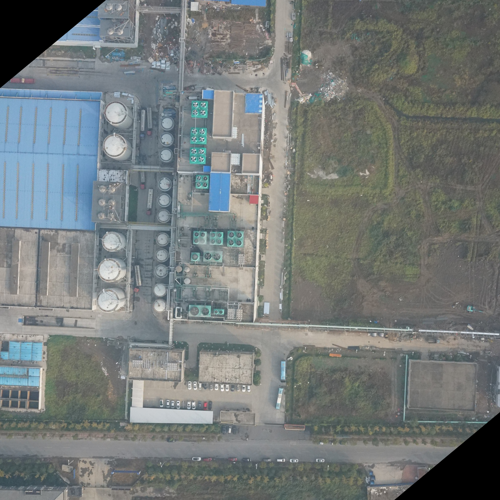

In [8]:
if POSE_CSV_PATH is not None and Path(POSE_CSV_PATH).exists():
    img_raw, img_processed, meta = process_uav(
        img_path=str(IMAGE_PATH),
        csv_path=str(POSE_CSV_PATH),
    )
    preprocess_mode = "process_uav"
else:
    img_raw, img_processed, meta = fallback_preprocess(IMAGE_PATH, out_size=500)
    preprocess_mode = "fallback_preprocess"

print("Preprocess mode:", preprocess_mode)
print("Meta:", meta)
img_processed

In [9]:
binary_mask, _ = segment_image(
    image=img_processed,
    model=model,
    device=DEVICE,
    score_threshold=SEGMENT_SCORE_THRESHOLD,
    min_area=SEGMENT_MIN_AREA,
    tolerance_px=SEGMENT_TOLERANCE_PX,
    contour_method="marching_squares",
)

contours = extract_contours_from_mask(
    binary_mask,
    min_area=SEGMENT_MIN_AREA,
    method="marching_squares",
)
polygons = [contour_to_polygon(contour, tolerance_px=SEGMENT_TOLERANCE_PX) for contour in contours]
contours, polygons = filter_large_polygons_dynamic(
    contours,
    polygons,
    image_shape=binary_mask.shape,
    quantile=MAX_SIZE_QUANTILE,
)
polygons = [polygon for polygon in polygons if len(polygon) >= 3]

triangle_records, descriptors = collect_triangle_records(polygons, max_depth=EKE_MAX_DEPTH)

print(f"Contours   : {len(contours)}")
print(f"Polygons   : {len(polygons)}")
print(f"Triangles  : {len(triangle_records)}")
print(f"Descriptors: {descriptors.shape}")

Contours   : 50
Polygons   : 50
Triangles  : 223
Descriptors: (223, 5)


## Lưu 7 ảnh stage riêng

Các file sẽ được lưu dưới `LocalizationUAV/notebooks/outputs/uav_stage_viz/<ten_anh>/`.
Stage 5.1 là bản mesh-only của CDT để bỏ lớp nhà phía sau bị chồng.

In [ ]:
base_rgb = np.asarray(img_processed.convert("RGB"))

if meta.get("yaw_applied") is not None:
    stage1_title = f"UAV Ekeland (North-up, yaw={float(meta['yaw_applied']):+.1f}° corrected)"
else:
    stage1_title = "UAV Ekeland (Preprocessed)"
if meta.get("height") is not None:
    stage1_title += f"\nheight={float(meta['height']):.0f} m"

stage_paths = {}
stage_paths["01_preprocessed"] = save_array_stage(
    base_rgb,
    OUTPUT_DIR / "01_preprocessed.png",
    stage1_title,
)
stage_paths["02_binary_mask"] = save_array_stage(
    binary_mask.astype(np.uint8) * 255,
    OUTPUT_DIR / "02_binary_mask.png",
    f"Binary Mask\n{len(polygons)} buildings",
    cmap="gray",
)
stage_paths["03_contours"] = save_array_stage(
    make_contour_overlay(base_rgb, contours),
    OUTPUT_DIR / "03_contours.png",
    f"Contours\n{len(contours)} detected",
)
stage_paths["04_polygons"] = save_array_stage(
    make_polygon_overlay(base_rgb, polygons),
    OUTPUT_DIR / "04_polygons.png",
    f"Polygons\n{sum(len(p) for p in polygons)} vertices",
)
stage_paths["05_cdt_mesh"] = save_figure_stage(
    make_cdt_figure(base_rgb, triangle_records),
    OUTPUT_DIR / "05_cdt_mesh.png",
)
stage_paths["05_1_cdt_mesh"] = save_figure_stage(
    make_cdt_mesh_only_figure(base_rgb, triangle_records),
    OUTPUT_DIR / "05_1_cdt_mesh.png",
)
stage_paths["06_ekeland_mfca"] = save_figure_stage(
    make_ekeland_figure(base_rgb, triangle_records, top_n=EKE_VISUAL_TOP_N),
    OUTPUT_DIR / "06_ekeland_mfca.png",
)

print("Saved stage images:")
for key, path in stage_paths.items():
    print(f"{key}: {path}")

stage_paths

Saved stage images:
01_preprocessed: D:\bk_study_stuff\paper6\LocalizationUAV\notebooks\outputs\uav_stage_viz\03_0049\01_preprocessed.png
02_binary_mask: D:\bk_study_stuff\paper6\LocalizationUAV\notebooks\outputs\uav_stage_viz\03_0049\02_binary_mask.png
03_contours: D:\bk_study_stuff\paper6\LocalizationUAV\notebooks\outputs\uav_stage_viz\03_0049\03_contours.png
04_polygons: D:\bk_study_stuff\paper6\LocalizationUAV\notebooks\outputs\uav_stage_viz\03_0049\04_polygons.png
05_cdt_mesh: D:\bk_study_stuff\paper6\LocalizationUAV\notebooks\outputs\uav_stage_viz\03_0049\05_cdt_mesh.png
05_1_cdt_mesh: D:\bk_study_stuff\paper6\LocalizationUAV\notebooks\outputs\uav_stage_viz\03_0049\05_1_cdt_mesh.png
06_ekeland_mfca: D:\bk_study_stuff\paper6\LocalizationUAV\notebooks\outputs\uav_stage_viz\03_0049\06_ekeland_mfca.png


{'01_preprocessed': WindowsPath('D:/bk_study_stuff/paper6/LocalizationUAV/notebooks/outputs/uav_stage_viz/03_0049/01_preprocessed.png'),
 '02_binary_mask': WindowsPath('D:/bk_study_stuff/paper6/LocalizationUAV/notebooks/outputs/uav_stage_viz/03_0049/02_binary_mask.png'),
 '03_contours': WindowsPath('D:/bk_study_stuff/paper6/LocalizationUAV/notebooks/outputs/uav_stage_viz/03_0049/03_contours.png'),
 '04_polygons': WindowsPath('D:/bk_study_stuff/paper6/LocalizationUAV/notebooks/outputs/uav_stage_viz/03_0049/04_polygons.png'),
 '05_cdt_mesh': WindowsPath('D:/bk_study_stuff/paper6/LocalizationUAV/notebooks/outputs/uav_stage_viz/03_0049/05_cdt_mesh.png'),
 '05_1_cdt_mesh': WindowsPath('D:/bk_study_stuff/paper6/LocalizationUAV/notebooks/outputs/uav_stage_viz/03_0049/05_1_cdt_mesh.png'),
 '06_ekeland_mfca': WindowsPath('D:/bk_study_stuff/paper6/LocalizationUAV/notebooks/outputs/uav_stage_viz/03_0049/06_ekeland_mfca.png')}

: 